## KNN without pca

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report as cr

# Load dataset (replace 'diabetes.csv' with your actual file)
df = pd.read_csv("diabetes.csv")  # Replace with your file path

# Assuming 'target' is the name of the column you're predicting
target = 'Outcome'  # Replace with your target column

# Separate features and target
x = df.drop([target], axis=1)
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

# Print train and test set shapes
print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)

# Define the number of neighbors
k = 5

# Train KNN models with different distance metrics
model_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
model_euclidean.fit(X_train, y_train)

model_minkowski = KNeighborsClassifier(n_neighbors=k, metric='minkowski')  # Default p=2 for Euclidean-like behavior
model_minkowski.fit(X_train, y_train)

model_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
model_manhattan.fit(X_train, y_train)

# Evaluate models on the test set and print classification reports
print("For Euclidean:\n", cr(y_test, model_euclidean.predict(X_test)))
print("\n\nFor Minkowski:\n", cr(y_test, model_minkowski.predict(X_test)))
print("\n\nFor Manhattan:\n", cr(y_test, model_manhattan.predict(X_test)))


Train set: (614, 8) (614,)
Test set: (154, 8) (154,)
For Euclidean:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       102
           1       0.60      0.56      0.58        52

    accuracy                           0.73       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



For Minkowski:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       102
           1       0.60      0.56      0.58        52

    accuracy                           0.73       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



For Manhattan:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       102
           1       0.68      0.58      0.62        52

    accuracy                           0.77       154
   macro avg       0.74

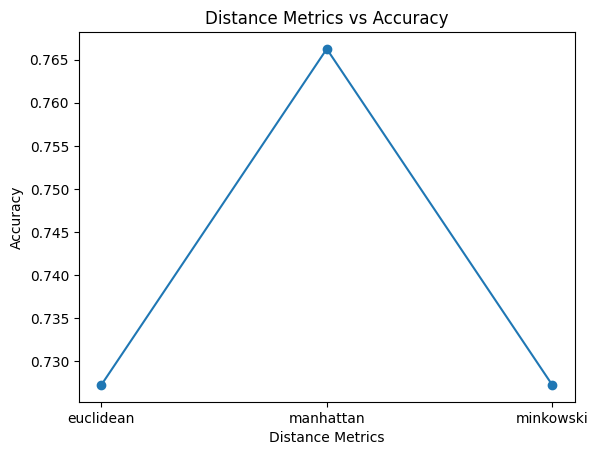

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as a_s

# Load data and prepare
df = pd.read_csv("diabetes.csv")  # Replace with your file path
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Train models and calculate accuracies
metrics = ['euclidean', 'manhattan', 'minkowski']
accuracies = [a_s(y_test, KNeighborsClassifier(n_neighbors=5, metric=m).fit(X_train, y_train).predict(X_test)) for m in metrics]

# Plot results
plt.plot(metrics, accuracies, marker='o')
plt.title("Distance Metrics vs Accuracy")
plt.xlabel("Distance Metrics")
plt.ylabel("Accuracy")
plt.show()


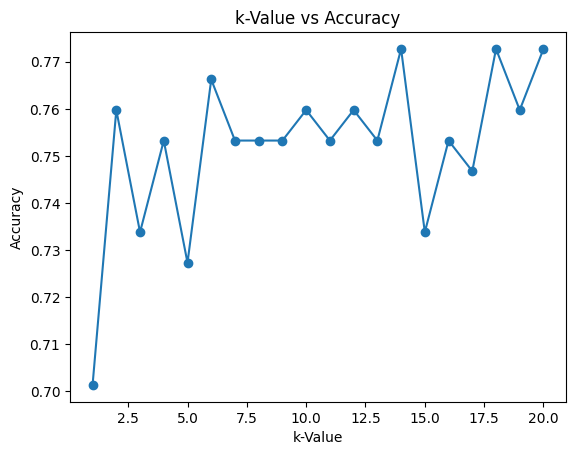

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as a_s

# Load data and prepare
df = pd.read_csv("diabetes.csv")  # Replace with your file path
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Calculate accuracies for different k-values
k_values = range(1, 21)  # k values from 1 to 20
accuracies = [a_s(y_test, KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_train, y_train).predict(X_test)) for k in k_values]

# Plot results
plt.plot(k_values, accuracies, marker='o')
plt.title("k-Value vs Accuracy")
plt.xlabel("k-Value")
plt.ylabel("Accuracy")
plt.show()


# KNN with PCA

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as a_s
from sklearn.metrics import classification_report as cr
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("diabetes.csv")  # Replace with your file path

# Select all columns except the target (assuming 'Outcome' is the target column)
X = df.drop(['Outcome'], axis=1)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with the reduced features
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Display the reduced DataFrame
print(df_pca.head(9))


          PC1        PC2
0  -75.714655 -35.950783
1  -82.358268  28.908213
2  -74.630643 -67.906496
3   11.077423  34.898486
4   89.743788  -2.746937
5  -80.977922  -3.946887
6    4.350959  46.933912
7  -82.137294   7.097954
8  468.866389 -31.528258


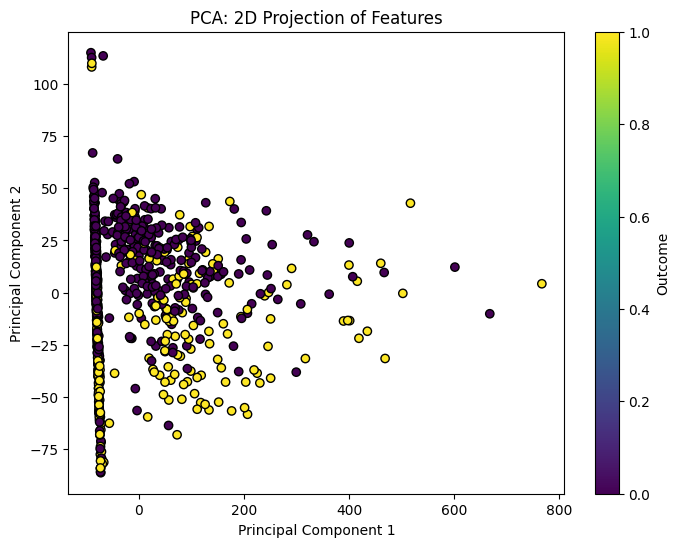

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df['Outcome'], cmap='viridis', edgecolor='k')
plt.title("PCA: 2D Projection of Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Outcome')
plt.show()

In [7]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=4)
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=metric)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nFor {metric}:\n", cr(y_test, y_pred))



For euclidean:
               precision    recall  f1-score   support

           0       0.84      0.77      0.81       102
           1       0.62      0.71      0.66        52

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.76       154


For manhattan:
               precision    recall  f1-score   support

           0       0.83      0.76      0.80       102
           1       0.60      0.69      0.64        52

    accuracy                           0.74       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154


For minkowski:
               precision    recall  f1-score   support

           0       0.84      0.77      0.81       102
           1       0.62      0.71      0.66        52

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76

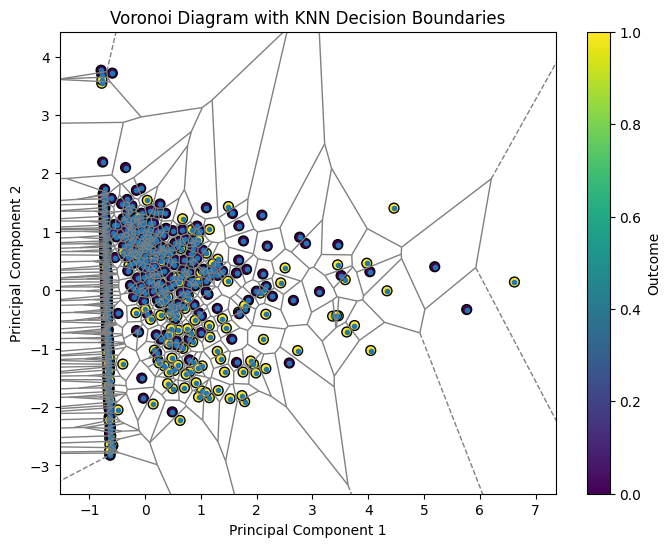

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import Voronoi, voronoi_plot_2d

X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=4)

model = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
model.fit(X_train, y_train)

# Create Voronoi diagram
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Create Voronoi cells for the training data
vor = Voronoi(X_scaled)

# Plot the Voronoi diagram
fig, ax = plt.subplots(figsize=(8, 6))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='gray')

# Scatter plot of the data points
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
ax.set_title("Voronoi Diagram with KNN Decision Boundaries")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

# Colorbar for target labels
cbar = plt.colorbar(scatter)
cbar.set_label('Outcome')

plt.show()
